In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_theme(style="whitegrid")

In [ ]:
df=pd.read_csv('/content/karachi properties handle missing values 3.csv')

In [ ]:
df.shape

(20331, 31)

In [ ]:
df[df['sub_location']=='North Nazimabad Block B']

,property_name,address,location,sub_location,price,price_crore,price_per_sqft,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,completion_year,property_type,property_age,age_category,parking_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score,age,property_type_encoded,floor_category
1,double storey house available for sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,100000000.0,10.00,22222.22,4500.0,5,5,1.0,Not_applicable,3.0,1.0,0,2.0,1,1,2023.0,house,3.0,Relatively New,2,900.000000,Karachi Central,Subdivision,4,2,3.0,1,Not_Applicable
4,north vista 2 bed d d flat for sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,16500000.0,1.65,17295.60,954.0,2,3,0.0,NaN,11.0,0.0,0,0.0,0,0,2020.0,flat,6.0,Moderately Old,0,477.000000,Karachi Central,Subdivision,4,2,6.0,0,Unknown
311,1600 sq ft well maintain new luxury flat for s...,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,32000000.0,3.20,19975.03,1602.0,3,3,1.0,NaN,13.0,1.0,1,1.0,1,1,2024.0,flat,2.0,Relatively New,1,534.000000,Karachi Central,Subdivision,4,2,2.0,0,Unknown
707,brand new double storey house available for sale,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,160000000.0,16.00,35555.56,4500.0,6,7,1.0,Not_applicable,2.0,1.0,0,2.0,1,1,2018.0,house,8.0,Moderately Old,2,750.000000,Karachi Central,Subdivision,4,2,8.0,1,Not_Applicable
809,house available for sale block b,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,60000000.0,6.00,24242.42,2475.0,5,5,2.0,Not_applicable,3.0,3.0,0,1.0,0,0,2015.0,house,11.0,Old,3,495.000000,Karachi Central,Subdivision,4,2,11.0,1,Not_Applicable
1328,flat for sale ground north vista north nazimab...,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,20000000.0,2.00,14245.01,1404.0,3,3,1.0,NaN,3.0,1.0,1,1.0,1,1,2015.0,flat,11.0,Old,1,468.000000,Karachi Central,Subdivision,4,2,11.0,0,Unknown
1544,3 bed dd bank loan applicable flat,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,29000000.0,2.90,18102.37,1602.0,3,3,1.0,3.0,12.0,1.0,1,1.0,1,1,2022.0,flat,4.0,Relatively New,1,534.000000,Karachi Central,Subdivision,4,2,4.0,0,3.0
1670,brand new modern and luxury flat available for...,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,15500000.0,1.55,14116.58,1098.0,2,2,1.0,NaN,3.0,1.0,1,0.0,1,1,2010.0,flat,16.0,Old,1,549.000000,Karachi Central,Subdivision,4,2,16.0,0,Unknown
1770,get in touch now to buy a flat in karachi,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,27500000.0,2.75,16166.96,1701.0,4,4,0.0,NaN,5.0,0.0,0,1.0,0,0,2014.0,flat,12.0,Old,0,425.250000,Karachi Central,Subdivision,4,2,12.0,0,Unknown
1922,double story one unit style house available fo...,"north nazimabad - block b, north nazimabad",North Nazimabad,North Nazimabad Block B,70000000.0,7.00,30381.94,2304.0,5,6,1.0,Not_applicable,2.0,1.0,0,1.0,1,1,2019.0,house,7.0,Moderately Old,2,460.800000,Karachi Central,Subdivision,4,2,7.0,1,Not_Applicable


In [ ]:
df.groupby('sub_location')['price_crore'].median().sort_values(ascending=False)

,price_crore
sub_location,
National Stadium Colony,70.0000
Kda Scheme 1 Extension,30.0000
Falcon Complex Faisal,27.0000
Mohammad Ali Society,24.5000
DHA Defence_Unspecified,21.2500
Navy Housing Scheme Karsaz,20.8750
Kda Scheme 1,20.0000
Dohs Phase 1,17.5000
Phase 2,16.0000


In [ ]:
# Compare median price per square foot by location and property type.

median_ppsf = (
    df
    .dropna(subset=["location", "property_type", "price_per_sqft"])
    .groupby(
        ["location", "property_type"]
    )["price_per_sqft"]
    .median()
    .unstack()
)

print(median_ppsf)

property_type              flat      house
location                                  
Bahria Town            7741.350  11466.670
Clifton               25372.580  42027.840
DHA Defence           34722.220  44117.650
Federal B Area        15116.485  27777.780
Gadap                  8196.720  14814.810
Gulistan-e-Jauhar     11907.645  27507.860
Gulshan-e-Iqbal Town  16232.280  34722.220
Jamshed Town          24774.770  44444.440
Karsaz                35399.030  71428.570
Korangi                5555.560  12531.330
Malir                 11445.280  25888.890
Malir Cantt           15737.505  26801.980
Naya Nazimabad        16103.060  36111.110
Nazimabad             13029.580  27454.205
North Karachi          8011.290  24074.070
North Nazimabad       15302.730  26111.110
Saddar Town           24149.145  14351.850
Scheme 33             12295.080  22685.190
Shah Faisal            7407.410  20734.125
Super Highway         11789.920  12152.780


In [ ]:
location_market_score = {
    # Highest-value areas with premium market appeal.
    "DHA Defence": 5,
    "Malir Cantt": 5,
    "Clifton": 5,
    "Karsaz": 5,

    # High-value areas with strong demand.
    "Gulshan-e-Iqbal Town": 4,
    "North Nazimabad": 4,
    "Jamshed Town": 4,
    "Naya Nazimabad": 4,

    # Established areas with moderate prices and growth potential.
    "Federal B Area": 3,
    "Gulistan-e-Jauhar": 3,
    "Saddar Town": 3,
    "Scheme 33": 3,
    "Bahria Town": 3,

    # More affordable areas with below-average market prices.
    "Nazimabad": 2,
    "Malir": 2,
    "North Karachi": 2,
    "Shah Faisal": 2,

    # Lower-priced, peripheral, or industrial areas.
    "Super Highway": 1,
    "Gadap": 1,
    "Korangi": 1,
}

df["location_score"] = df["location"].map(
    location_market_score
)

In [ ]:
# Compare median price per square foot by sub-location and property type.

median_ppsf = (
    df
    .dropna(subset=["sub_location", "property_type", "price_crore"])
    .groupby(
        ["sub_location", "property_type"]
    )["price_crore"]
    .median()
    .unstack()
)

print(median_ppsf)

property_type                                flat   house
sub_location                                             
Adamjee Nagar                              5.1250  16.250
Airport                                    1.9500   3.000
Allahwala Town                             0.2500   3.950
Amil Colony                                3.2250  57.500
Amir Khusro                                3.5000  14.200
Askari 4                                   6.9000  20.250
Askari 5                                   4.3500   9.550
Askari 6                                   4.0000   7.640
Bahadurabad                                4.5000  12.000
Bahria Apartments                          0.8350     NaN
Bahria Heights                             0.8100   0.900
Bahria Paradise                               NaN   4.600
Bahria Sports City                            NaN   2.000
Bahria Town_Unspecified                    0.9050   2.725
Bath Island                                7.3500  11.000
Buffer Zone   

In [ ]:
df['sub_location_score']=np.nan

In [ ]:
sub_location_score_mapping = {

    
    # PREMIUM / VERY HIGH VALUE
    

    "Navy Housing Scheme Karsaz": 5,
    "National Stadium Colony": 5,
    "DHA Defence_Unspecified": 5,
    "Clifton Block 4": 5,
    "Clifton Block 6": 5,
    "Clifton Block 8": 5,
    "Clifton Block 9": 5,
    "Clifton_Unspecified": 5,
    "Bath Island": 5,
    "Civil Lines": 5,
    "Phase 8": 5,
    "Phase 1": 5,
    "KDA Scheme 1": 5,
    "KDA Scheme 1 Extension": 5,
    "Gizri": 5,
    "Khalid Bin Walid Road": 5,
    "Shaheed Millat Road": 5,
    "Tipu Sultan Road": 5,
    "Shahra-E-Qaideen": 5,
    "Mohammad Ali Society": 5,
    "Amir Khusro": 5,

    
    # HIGH VALUE
    

    "Clifton Block 2": 5,
    "Clifton Block 3": 5,
    "Clifton Block 5": 4,
    "Clifton Block 7": 5,
    "Clifton Block 1": 4,

    "Askari 4": 5,
    "Askari 5": 4,
    "Askari 6": 4,

    "Pechs": 4,
    "Bahadurabad": 4,
    "Sharfabad": 4,
    "Smchs - Sindhi Muslim Society": 5,
    "Cosmopolitan Society": 4,
    "Frere Town": 4,

    "Qayyumabad": 4,
    "Dhoraji Colony": 4,
    "Garden East": 4,
    "Tariq Road": 4,

    "Gulshan-e-Iqbal Block 16": 4,
    "Gulshan-e-Iqbal Block 17": 4,
    "Gulshan-e-Iqbal Block 10A": 4,
    "Gulshan-e-Iqbal Block 13A": 4,
    "Gulshan-e-Iqbal Block 13D": 4,

    "Gulistan-e-Jauhar Block 1": 4,
    "Gulistan-e-Jauhar Block 15": 4,
    "Gulistan-e-Jauhar Block 16": 4,
    "Gulistan-e-Jauhar Block 16A": 4,
    "Gulistan-e-Jauhar Block 20": 4,

    "North Nazimabad Block B": 4,
    "North Nazimabad Block C": 4,
    "North Nazimabad Block D": 4,
    "North Nazimabad Block F": 4,
    "North Nazimabad Block L": 4,
    "North Nazimabad Block N": 4,

    "Federal B Area Block 21": 4,
    "Federal B Area Block 10": 4,
    "Federal B Area Block 6": 4,

    "Jamshed Town_Unspecified": 4,
    "Jamshed Road": 4,

    
    # UPPER-MIDDLE
    

    "Adamjee Nagar": 3,
    "Airport": 3,
    "Amil Colony": 4,
    "Falcon Complex Faisal": 4,
    "Falcon Complex New Malir": 3,

    "DHA City": 3,
    "Defence View": 3,

    "Garden West": 3,
    "Gulshan-E-Maymar": 3,

    "Gulshan-e-Iqbal Block 1": 3,
    "Gulshan-e-Iqbal Block 2": 3,
    "Gulshan-e-Iqbal Block 3": 3,
    "Gulshan-e-Iqbal Block 4": 3,
    "Gulshan-e-Iqbal Block 5": 3,
    "Gulshan-e-Iqbal Block 6": 3,
    "Gulshan-e-Iqbal Block 7": 3,
    "Gulshan-e-Iqbal Block 10": 3,
    "Gulshan-e-Iqbal Block 11": 3,
    "Gulshan-e-Iqbal Block 13": 3,
    "Gulshan-e-Iqbal Block 13C": 3,
    "Gulshan-e-Iqbal Block 13D1": 3,
    "Gulshan-e-Iqbal Block 13D2": 3,
    "Gulshan-e-Iqbal Block 13D3": 3,
    "Gulshan-e-Iqbal Block 14": 3,
    "Gulshan-e-Iqbal Block 19": 3,
    "Gulshan-e-Iqbal Block 21": 3,
    "Gulshan-e-Iqbal Town_Unspecified": 3,

    "Gulistan-e-Jauhar Block 2": 3,
    "Gulistan-e-Jauhar Block 3": 3,
    "Gulistan-e-Jauhar Block 3A": 3,
    "Gulistan-e-Jauhar Block 5": 3,
    "Gulistan-e-Jauhar Block 7": 3,
    "Gulistan-e-Jauhar Block 10": 3,
    "Gulistan-e-Jauhar Block 12": 3,
    "Gulistan-e-Jauhar Block 13": 3,
    "Gulistan-e-Jauhar Block 14": 3,
    "Gulistan-e-Jauhar Block 18": 3,
    "Gulistan-e-Jauhar Block 19": 3,
    "Gulistan-e-Jauhar_Unspecified": 3,

    "North Nazimabad Block A": 3,
    "North Nazimabad Block H": 3,
    "North Nazimabad Block I": 3,
    "North Nazimabad Block J": 3,
    "North Nazimabad Block M": 3,
    "North Nazimabad_Unspecified": 3,

    "Nazimabad 3": 3,
    "Nazimabad 4": 3,
    "Nazimabad 5": 3,
    "Nazimabad 1": 3,
    "Nazimabad 2": 3,

    "Federal B Area Block 12": 3,
    "Federal B Area Block 13": 3,
    "Federal B Area Block 20": 3,
    "Federal B Area Block 8": 3,
    "Federal B Area Block 9": 3,
    "Federal B Area_Unspecified": 3,

    "Karachi Administration Employees Society": 3,
    "Meerut Society": 3,
    "Muslimabad Society": 3,
    "Kda Employees Society": 2,

    "Mehmoodabad": 3,
    "Model Colony": 3,
    "Malir Cantt_Unspecified": 3,
    "Malir_Unspecified": 2,

    "Naya Nazimabad Block A": 3,
    "Naya Nazimabad Block B": 3,
    "Naya Nazimabad Block C": 3,
    "Naya Nazimabad Block D": 3,
    "Naya Nazimabad Block M": 3,
    "Naya Nazimabad_Unspecified": 3,

    "Shadman": 3,
    "Shah Faisal_Unspecified": 2,
    "Shahrah-E-Pakistan": 3,
    "Soldier Bazar": 3,

    "Precinct 17": 3,
    "Precinct 18": 3,
    "Precinct 19": 3,

    # MID / AVERAGE


    "Allahwala Town": 2,
    "Buffer Zone": 2,
    "Dohs Phase 1": 4,
    "Dohs Phase 2": 4,

    "Gohar Green City Cluster": 2,
    "Golden Town": 2,
    "Green Town / Rafah-E-Aam Belt": 2,

    "Gulistan-e-Jauhar Block 4": 2,
    "Gulistan-e-Jauhar Block 8": 2,
    "Gulistan-e-Jauhar Block 9": 2,
    "Gulistan-e-Jauhar Block 11": 2,
    "Gulistan-e-Jauhar Block 17": 2,

    "Gulshan-e-Usman Housing Society": 2,

    "Jamia Millia Road": 2,
    "Korangi Industrial Area": 1,

    "Malir Link To Super Highway": 2,
    "Malir Town Residency": 2,
    "Memon Goth": 2,

    "New Karachi": 2,

    "North Karachi Sector 5": 2,
    "North Karachi Sector 7": 2,
    "North Karachi Sector 8": 2,
    "North Karachi Sector 9": 2,
    "North Karachi Sector 10": 2,
    "North Karachi Sector 11": 2,
    "North Karachi_Unspecified": 2,

    "Oasis Park Residencia": 2,

    "Parsi Colony": 3,

    "Precinct 1": 2,
    "Precinct 2": 2,
    "Precinct 4": 2,
    "Precinct 6": 2,
    "Precinct 7": 2,
    "Precinct 8": 2,
    "Precinct 9": 2,
    "Precinct 10A": 2,
    "Precinct 10B": 2,
    "Precinct 11A": 2,
    "Precinct 11B": 2,
    "Precinct 12": 2,
    "Precinct 15": 2,
    "Precinct 16": 2,
    "Precinct 27": 2,
    "Precinct 31": 2,

    "Punjabi Saudagar Society": 2,
    "Saadi Garden": 2,
    "Saadi Road": 2,
    "Saddar Core": 3,
    "Safoora Goth": 2,

    "Saima Luxury Belt": 2,
    "Saima Projects": 2,
    "Saima Villas": 2,

    "Scheme 33_Unspecified": 2,

    "Sector 15-A": 2,
    "Sector 16-A": 2,
    "Sector 17-A": 2,
    "Sector 17-B": 2,
    "Sector 18-A": 2,
    "Sector 18-C": 2,
    "Sector 19-A": 2,
    "Sector 20-A": 2,
    "Sector 22-A": 2,
    "Sector 24-A": 2,
    "Sector 24-B": 2,
    "Sector 25-B": 2,
    "Sector 29": 2,
    "Sector 30": 2,
    "Sector 34-A": 2,
    "Sector 35-A": 2,
    "Sector 36-A": 2,
    "Sector 38-A": 2,
    "Sector 40": 2,
    "Sector 42-A": 2,
    "Sector 43-A": 2,
    "Sector 44": 2,
    "Sector 45-A": 2,
    "Sector 47": 2,
    "Sector 48-A": 2,
    "Sector 51-A": 2,
    "Sector 52-A": 2,

    "Shamsi / Al-Falah Belt": 2,
    "Super Highway_Unspecified": 2,
    "Surjani Town": 1,

    
    # LOWER VALUE
    

    "Bahria Apartments": 2,
    "Bahria Heights": 2,
    "Bahria Paradise": 2,
    "Bahria Sports City": 2,
    "Bahria Town_Unspecified": 2,

    "Falaknaz": 2,

    "Federal B Area Block 14": 2,
    "Federal B Area Block 15": 2,
    "Federal B Area Block 16": 2,
    "Federal B Area Block 19": 2,
    "Federal B Area Block 7": 2,

    "Precinct 10A": 2,
    "Precinct 10B": 2,
    "Precinct 11A": 2,
    "Precinct 11B": 2,
    "Precinct 12": 2,
    "Precinct 15": 2,
    "Precinct 16": 2,

    "Saima Luxury Belt": 2,

    "Shah Faisal_Unspecified": 2,

    "Surjani Town": 1,



    "Phase 6": 5,
    "Phase 5": 5,
    "Phase 7": 5,
    "Phase 4": 4,
    "Phase 7 Extension": 4,

    "Kda Scheme 1": 5,
    "Private High-Rises": 4,

    "Phase 2 Extension": 3,
    "Phase 2": 4,

    "North Nazimabad Block K": 3,
    "Federal B Area Block 11": 3,

    "Gulshan-e-Iqbal Block 13B": 3,
    "Phase 5 Extension": 5,

    "North Nazimabad Block G": 3,
    "Gulshan-e-Iqbal Block 9": 3,

    "Cp Barar Society, Gulshan-E-Iqbal Town": 3,

    "Phase 8 Extension": 5,

    "Kda Scheme 1 Extension": 5
}
df["sub_location_score"] = df["sub_location"].map(sub_location_score_mapping)

In [ ]:
df.groupby('sub_location_score')['price_crore'].agg(['median','count','mean'])

,median,count,mean
sub_location_score,,,
1,0.875,228,1.060899
2,1.900,5470,2.402546
3,3.100,5377,4.746472
4,4.850,4009,7.116528
5,9.500,5247,14.541925


In [ ]:
train_df=df.drop(columns='price_per_sqft')

In [ ]:
train_df.drop(columns=['completion_year','age'],inplace=True)

In [ ]:
df.shape

(20331, 31)

In [ ]:
train_df.drop(columns=['property_name','address','property_type'],inplace=True)

In [ ]:
train_df['parking_score'].unique()

array([3, 2, 0, 1, 5, 4])

In [ ]:
train_df.head()

,location,sub_location,price,price_crore,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,property_age,age_category,parking_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score,property_type_encoded,floor_category
0,Scheme 33,Sector 47,22800000.0,2.28,1080.0,4,5,1.0,Not_applicable,2.0,3.0,0,0.0,1,1,1.0,Relatively New,3,270.00,Karachi East,Subdivision,3,2,1,Not_Applicable
1,North Nazimabad,North Nazimabad Block B,100000000.0,10.00,4500.0,5,5,1.0,Not_applicable,3.0,1.0,0,2.0,1,1,3.0,Relatively New,2,900.00,Karachi Central,Subdivision,4,4,1,Not_Applicable
2,North Nazimabad,North Nazimabad Block F,25500000.0,2.55,1494.0,3,3,0.0,NaN,12.0,0.0,1,1.0,1,0,7.0,Moderately Old,0,498.00,Karachi Central,Subdivision,4,4,0,Unknown
3,Jamshed Town,Pechs,65000000.0,6.50,2403.0,4,4,2.0,NaN,15.0,2.0,0,1.0,1,0,4.0,Relatively New,1,600.75,Karachi East,Society,4,4,0,Unknown
4,North Nazimabad,North Nazimabad Block B,16500000.0,1.65,954.0,2,3,0.0,NaN,11.0,0.0,0,0.0,0,0,6.0,Moderately Old,0,477.00,Karachi Central,Subdivision,4,4,0,Unknown


In [ ]:
df['floor'].value_counts()

,count
floor,
Not_applicable,9856
1.0,728
2.0,616
3.0,557
4.0,415
5.0,309
6.0,215
8.0,167
7.0,158


In [ ]:
train_df.loc[df['floor']=='Not_applicable','floor']=np.nan
train_df["floor"] = pd.to_numeric(df["floor"], errors="coerce")

In [ ]:
def categorize_floor(row):
    if row["property_type_encoded"] == 1:
        return "Not Applicable"

    if pd.isna(row["floor"]):
        return "Unknown"

    floor = row["floor"]

    if floor == 0:
        return "Ground Floor"
    elif floor <= 3:
        return "Low Floor"
    elif floor <= 7:
        return "Mid Floor"
    elif floor <= 15:
        return "High Floor"
    else:
        return "Very High Floor"

train_df["floor_category"] = train_df.apply(categorize_floor, axis=1)

In [ ]:
train_df.head()

,location,sub_location,price,price_crore,area,bedrooms,bathrooms,kitchen,floor,total_floors,parking,elevator,servant_quarters,electricity_backup,furnished,property_age,age_category,parking_score,area_per_bedroom,district,sub_location_type,location_score,sub_location_score,property_type_encoded,floor_category
0,Scheme 33,Sector 47,22800000.0,2.28,1080.0,4,5,1.0,NaN,2.0,3.0,0,0.0,1,1,1.0,Relatively New,3,270.00,Karachi East,Subdivision,3,2,1,Not Applicable
1,North Nazimabad,North Nazimabad Block B,100000000.0,10.00,4500.0,5,5,1.0,NaN,3.0,1.0,0,2.0,1,1,3.0,Relatively New,2,900.00,Karachi Central,Subdivision,4,4,1,Not Applicable
2,North Nazimabad,North Nazimabad Block F,25500000.0,2.55,1494.0,3,3,0.0,NaN,12.0,0.0,1,1.0,1,0,7.0,Moderately Old,0,498.00,Karachi Central,Subdivision,4,4,0,Unknown
3,Jamshed Town,Pechs,65000000.0,6.50,2403.0,4,4,2.0,NaN,15.0,2.0,0,1.0,1,0,4.0,Relatively New,1,600.75,Karachi East,Society,4,4,0,Unknown
4,North Nazimabad,North Nazimabad Block B,16500000.0,1.65,954.0,2,3,0.0,NaN,11.0,0.0,0,0.0,0,0,6.0,Moderately Old,0,477.00,Karachi Central,Subdivision,4,4,0,Unknown


In [ ]:
train_df.drop(columns=['parking','price_crore','floor','property_age'],inplace=True)

In [ ]:
train_df['floor_category'].value_counts()

,count
floor_category,
Not Applicable,9856
Unknown,6558
Low Floor,1901
Mid Floor,1097
High Floor,613
Very High Floor,221
Ground Floor,85


In [ ]:
# Encode categorical columns before training the model.
from sklearn.compose import  ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

one_hot_cols=[
    "district",
    "location",
    "sub_location",
    "floor_category",
    "sub_location_type"
]

ordinal_cols=['age_category']

age_order = [
    "Under Construction",
    "New",
    "Relatively New",
    "Moderately Old",
    "Old"
]


preprocessor=ColumnTransformer(
    transformers=[
         (
           "onehot",
           OneHotEncoder(
               handle_unknown='ignore',
               sparse_output=False
           ),
           one_hot_cols
         ),
         (
            "ordinal",
            OrdinalEncoder(
                categories=[age_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ordinal_cols
         )

    ],
    remainder="passthrough"
)
X = train_df.drop("price", axis=1)
y = train_df["price"]

X_encoded=preprocessor.fit_transform(X)
print(X_encoded.shape)



(20331, 302)


In [ ]:
train_df['age_category'].unique()

array(['Relatively New', 'Moderately Old', 'Old', 'New',
       'Under Construction'], dtype=object)

In [ ]:
df['sub_location_type'].value_counts()

,count
sub_location_type,
Subdivision,13026
Neighbourhood,1947
Military Housing,1754
Unspecified,1311
Society,873
Residential Project,813
Road,607


In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=feature_names,
    index=X.index
)

X_encoded_df.head()

,onehot__district_Karachi Central,onehot__district_Karachi East,onehot__district_Karachi South,onehot__district_Korangi,onehot__district_Malir,onehot__district_Multi-District,onehot__location_Bahria Town,onehot__location_Clifton,onehot__location_DHA Defence,onehot__location_Federal B Area,onehot__location_Gadap,onehot__location_Gulistan-e-Jauhar,onehot__location_Gulshan-e-Iqbal Town,onehot__location_Jamshed Town,onehot__location_Karsaz,onehot__location_Korangi,onehot__location_Malir,onehot__location_Malir Cantt,onehot__location_Naya Nazimabad,onehot__location_Nazimabad,onehot__location_North Karachi,onehot__location_North Nazimabad,onehot__location_Saddar Town,onehot__location_Scheme 33,onehot__location_Shah Faisal,onehot__location_Super Highway,onehot__sub_location_Adamjee Nagar,onehot__sub_location_Airport,onehot__sub_location_Allahwala Town,onehot__sub_location_Amil Colony,onehot__sub_location_Amir Khusro,onehot__sub_location_Askari 4,onehot__sub_location_Askari 5,onehot__sub_location_Askari 6,onehot__sub_location_Bahadurabad,onehot__sub_location_Bahria Apartments,onehot__sub_location_Bahria Heights,onehot__sub_location_Bahria Paradise,onehot__sub_location_Bahria Sports City,onehot__sub_location_Bahria Town_Unspecified,onehot__sub_location_Bath Island,onehot__sub_location_Buffer Zone,onehot__sub_location_Civil Lines,onehot__sub_location_Clifton Block 1,onehot__sub_location_Clifton Block 2,onehot__sub_location_Clifton Block 3,onehot__sub_location_Clifton Block 4,onehot__sub_location_Clifton Block 5,onehot__sub_location_Clifton Block 6,onehot__sub_location_Clifton Block 7,onehot__sub_location_Clifton Block 8,onehot__sub_location_Clifton Block 9,onehot__sub_location_Clifton_Unspecified,onehot__sub_location_Cosmopolitan Society,"onehot__sub_location_Cp Barar Society, Gulshan-E-Iqbal Town",onehot__sub_location_DHA City,onehot__sub_location_DHA Defence_Unspecified,onehot__sub_location_Defence View,onehot__sub_location_Dhoraji Colony,onehot__sub_location_Dohs Phase 1,onehot__sub_location_Dohs Phase 2,onehot__sub_location_Falaknaz,onehot__sub_location_Falcon Complex Faisal,onehot__sub_location_Falcon Complex New Malir,onehot__sub_location_Federal B Area Block 10,onehot__sub_location_Federal B Area Block 11,onehot__sub_location_Federal B Area Block 12,onehot__sub_location_Federal B Area Block 13,onehot__sub_location_Federal B Area Block 14,onehot__sub_location_Federal B Area Block 15,onehot__sub_location_Federal B Area Block 16,onehot__sub_location_Federal B Area Block 19,onehot__sub_location_Federal B Area Block 20,onehot__sub_location_Federal B Area Block 21,onehot__sub_location_Federal B Area Block 6,onehot__sub_location_Federal B Area Block 7,onehot__sub_location_Federal B Area Block 8,onehot__sub_location_Federal B Area Block 9,onehot__sub_location_Federal B Area_Unspecified,onehot__sub_location_Frere Town,onehot__sub_location_Garden East,onehot__sub_location_Garden West,onehot__sub_location_Gizri,onehot__sub_location_Gohar Green City Cluster,onehot__sub_location_Golden Town,onehot__sub_location_Green Town / Rafah-E-Aam Belt,onehot__sub_location_Gulistan-e-Jauhar Block 1,onehot__sub_location_Gulistan-e-Jauhar Block 10,onehot__sub_location_Gulistan-e-Jauhar Block 11,onehot__sub_location_Gulistan-e-Jauhar Block 12,onehot__sub_location_Gulistan-e-Jauhar Block 13,onehot__sub_location_Gulistan-e-Jauhar Block 14,onehot__sub_location_Gulistan-e-Jauhar Block 15,onehot__sub_location_Gulistan-e-Jauhar Block 16,onehot__sub_location_Gulistan-e-Jauhar Block 16A,onehot__sub_location_Gulistan-e-Jauhar Block 17,onehot__sub_location_Gulistan-e-Jauhar Block 18,onehot__sub_location_Gulistan-e-Jauhar Block 19,onehot__sub_location_Gulistan-e-Jauhar Block 2,onehot__sub_location_Gulistan-e-Jauhar Block 20,onehot__sub_location_Gulistan-e-Jauhar Block 3,onehot__sub_location_Gulistan-e-Jauhar Block 3A,onehot__sub_location_Gulistan-e-Jauhar Block 4,onehot__sub_location_Gulistan-e-Jauhar Block 5,onehot__sub_location_Gulistan-e-Jauhar Block 7,onehot__sub_l

In [ ]:
X_encoded_df.columns.tolist()

['onehot__district_Karachi Central',
 'onehot__district_Karachi East',
 'onehot__district_Karachi South',
 'onehot__district_Korangi',
 'onehot__district_Malir',
 'onehot__district_Multi-District',
 'onehot__location_Bahria Town',
 'onehot__location_Clifton',
 'onehot__location_DHA Defence',
 'onehot__location_Federal B Area',
 'onehot__location_Gadap',
 'onehot__location_Gulistan-e-Jauhar',
 'onehot__location_Gulshan-e-Iqbal Town',
 'onehot__location_Jamshed Town',
 'onehot__location_Karsaz',
 'onehot__location_Korangi',
 'onehot__location_Malir',
 'onehot__location_Malir Cantt',
 'onehot__location_Naya Nazimabad',
 'onehot__location_Nazimabad',
 'onehot__location_North Karachi',
 'onehot__location_North Nazimabad',
 'onehot__location_Saddar Town',
 'onehot__location_Scheme 33',
 'onehot__location_Shah Faisal',
 'onehot__location_Super Highway',
 'onehot__sub_location_Adamjee Nagar',
 'onehot__sub_location_Airport',
 'onehot__sub_location_Allahwala Town',
 'onehot__sub_location_Amil C

# Technique 1 - Correlation Analysis

In [ ]:
X_encoded_df.head()

,onehot__district_Karachi Central,onehot__district_Karachi East,onehot__district_Karachi South,onehot__district_Korangi,onehot__district_Malir,onehot__district_Multi-District,onehot__location_Bahria Town,onehot__location_Clifton,onehot__location_DHA Defence,onehot__location_Federal B Area,onehot__location_Gadap,onehot__location_Gulistan-e-Jauhar,onehot__location_Gulshan-e-Iqbal Town,onehot__location_Jamshed Town,onehot__location_Karsaz,onehot__location_Korangi,onehot__location_Malir,onehot__location_Malir Cantt,onehot__location_Naya Nazimabad,onehot__location_Nazimabad,onehot__location_North Karachi,onehot__location_North Nazimabad,onehot__location_Saddar Town,onehot__location_Scheme 33,onehot__location_Shah Faisal,onehot__location_Super Highway,onehot__sub_location_Adamjee Nagar,onehot__sub_location_Airport,onehot__sub_location_Allahwala Town,onehot__sub_location_Amil Colony,onehot__sub_location_Amir Khusro,onehot__sub_location_Askari 4,onehot__sub_location_Askari 5,onehot__sub_location_Askari 6,onehot__sub_location_Bahadurabad,onehot__sub_location_Bahria Apartments,onehot__sub_location_Bahria Heights,onehot__sub_location_Bahria Paradise,onehot__sub_location_Bahria Sports City,onehot__sub_location_Bahria Town_Unspecified,onehot__sub_location_Bath Island,onehot__sub_location_Buffer Zone,onehot__sub_location_Civil Lines,onehot__sub_location_Clifton Block 1,onehot__sub_location_Clifton Block 2,onehot__sub_location_Clifton Block 3,onehot__sub_location_Clifton Block 4,onehot__sub_location_Clifton Block 5,onehot__sub_location_Clifton Block 6,onehot__sub_location_Clifton Block 7,onehot__sub_location_Clifton Block 8,onehot__sub_location_Clifton Block 9,onehot__sub_location_Clifton_Unspecified,onehot__sub_location_Cosmopolitan Society,"onehot__sub_location_Cp Barar Society, Gulshan-E-Iqbal Town",onehot__sub_location_DHA City,onehot__sub_location_DHA Defence_Unspecified,onehot__sub_location_Defence View,onehot__sub_location_Dhoraji Colony,onehot__sub_location_Dohs Phase 1,onehot__sub_location_Dohs Phase 2,onehot__sub_location_Falaknaz,onehot__sub_location_Falcon Complex Faisal,onehot__sub_location_Falcon Complex New Malir,onehot__sub_location_Federal B Area Block 10,onehot__sub_location_Federal B Area Block 11,onehot__sub_location_Federal B Area Block 12,onehot__sub_location_Federal B Area Block 13,onehot__sub_location_Federal B Area Block 14,onehot__sub_location_Federal B Area Block 15,onehot__sub_location_Federal B Area Block 16,onehot__sub_location_Federal B Area Block 19,onehot__sub_location_Federal B Area Block 20,onehot__sub_location_Federal B Area Block 21,onehot__sub_location_Federal B Area Block 6,onehot__sub_location_Federal B Area Block 7,onehot__sub_location_Federal B Area Block 8,onehot__sub_location_Federal B Area Block 9,onehot__sub_location_Federal B Area_Unspecified,onehot__sub_location_Frere Town,onehot__sub_location_Garden East,onehot__sub_location_Garden West,onehot__sub_location_Gizri,onehot__sub_location_Gohar Green City Cluster,onehot__sub_location_Golden Town,onehot__sub_location_Green Town / Rafah-E-Aam Belt,onehot__sub_location_Gulistan-e-Jauhar Block 1,onehot__sub_location_Gulistan-e-Jauhar Block 10,onehot__sub_location_Gulistan-e-Jauhar Block 11,onehot__sub_location_Gulistan-e-Jauhar Block 12,onehot__sub_location_Gulistan-e-Jauhar Block 13,onehot__sub_location_Gulistan-e-Jauhar Block 14,onehot__sub_location_Gulistan-e-Jauhar Block 15,onehot__sub_location_Gulistan-e-Jauhar Block 16,onehot__sub_location_Gulistan-e-Jauhar Block 16A,onehot__sub_location_Gulistan-e-Jauhar Block 17,onehot__sub_location_Gulistan-e-Jauhar Block 18,onehot__sub_location_Gulistan-e-Jauhar Block 19,onehot__sub_location_Gulistan-e-Jauhar Block 2,onehot__sub_location_Gulistan-e-Jauhar Block 20,onehot__sub_location_Gulistan-e-Jauhar Block 3,onehot__sub_location_Gulistan-e-Jauhar Block 3A,onehot__sub_location_Gulistan-e-Jauhar Block 4,onehot__sub_location_Gulistan-e-Jauhar Block 5,onehot__sub_location_Gulistan-e-Jauhar Block 7,onehot__sub_l

In [ ]:
X_encoded_df.columns = (
    X_encoded_df.columns
    .str.replace("remainder__", "", regex=False)
    .str.replace("ordinal__", "", regex=False)
    .str.replace("onehot__", "", regex=False)
)

In [ ]:
X_encoded_df.head()

,district_Karachi Central,district_Karachi East,district_Karachi South,district_Korangi,district_Malir,district_Multi-District,location_Bahria Town,location_Clifton,location_DHA Defence,location_Federal B Area,location_Gadap,location_Gulistan-e-Jauhar,location_Gulshan-e-Iqbal Town,location_Jamshed Town,location_Karsaz,location_Korangi,location_Malir,location_Malir Cantt,location_Naya Nazimabad,location_Nazimabad,location_North Karachi,location_North Nazimabad,location_Saddar Town,location_Scheme 33,location_Shah Faisal,location_Super Highway,sub_location_Adamjee Nagar,sub_location_Airport,sub_location_Allahwala Town,sub_location_Amil Colony,sub_location_Amir Khusro,sub_location_Askari 4,sub_location_Askari 5,sub_location_Askari 6,sub_location_Bahadurabad,sub_location_Bahria Apartments,sub_location_Bahria Heights,sub_location_Bahria Paradise,sub_location_Bahria Sports City,sub_location_Bahria Town_Unspecified,sub_location_Bath Island,sub_location_Buffer Zone,sub_location_Civil Lines,sub_location_Clifton Block 1,sub_location_Clifton Block 2,sub_location_Clifton Block 3,sub_location_Clifton Block 4,sub_location_Clifton Block 5,sub_location_Clifton Block 6,sub_location_Clifton Block 7,sub_location_Clifton Block 8,sub_location_Clifton Block 9,sub_location_Clifton_Unspecified,sub_location_Cosmopolitan Society,"sub_location_Cp Barar Society, Gulshan-E-Iqbal Town",sub_location_DHA City,sub_location_DHA Defence_Unspecified,sub_location_Defence View,sub_location_Dhoraji Colony,sub_location_Dohs Phase 1,sub_location_Dohs Phase 2,sub_location_Falaknaz,sub_location_Falcon Complex Faisal,sub_location_Falcon Complex New Malir,sub_location_Federal B Area Block 10,sub_location_Federal B Area Block 11,sub_location_Federal B Area Block 12,sub_location_Federal B Area Block 13,sub_location_Federal B Area Block 14,sub_location_Federal B Area Block 15,sub_location_Federal B Area Block 16,sub_location_Federal B Area Block 19,sub_location_Federal B Area Block 20,sub_location_Federal B Area Block 21,sub_location_Federal B Area Block 6,sub_location_Federal B Area Block 7,sub_location_Federal B Area Block 8,sub_location_Federal B Area Block 9,sub_location_Federal B Area_Unspecified,sub_location_Frere Town,sub_location_Garden East,sub_location_Garden West,sub_location_Gizri,sub_location_Gohar Green City Cluster,sub_location_Golden Town,sub_location_Green Town / Rafah-E-Aam Belt,sub_location_Gulistan-e-Jauhar Block 1,sub_location_Gulistan-e-Jauhar Block 10,sub_location_Gulistan-e-Jauhar Block 11,sub_location_Gulistan-e-Jauhar Block 12,sub_location_Gulistan-e-Jauhar Block 13,sub_location_Gulistan-e-Jauhar Block 14,sub_location_Gulistan-e-Jauhar Block 15,sub_location_Gulistan-e-Jauhar Block 16,sub_location_Gulistan-e-Jauhar Block 16A,sub_location_Gulistan-e-Jauhar Block 17,sub_location_Gulistan-e-Jauhar Block 18,sub_location_Gulistan-e-Jauhar Block 19,sub_location_Gulistan-e-Jauhar Block 2,sub_location_Gulistan-e-Jauhar Block 20,sub_location_Gulistan-e-Jauhar Block 3,sub_location_Gulistan-e-Jauhar Block 3A,sub_location_Gulistan-e-Jauhar Block 4,sub_location_Gulistan-e-Jauhar Block 5,sub_location_Gulistan-e-Jauhar Block 7,sub_location_Gulistan-e-Jauhar Block 8,sub_location_Gulistan-e-Jauhar Block 9,sub_location_Gulistan-e-Jauhar_Unspecified,sub_location_Gulshan-E-Maymar,sub_location_Gulshan-e-Iqbal Block 1,sub_location_Gulshan-e-Iqbal Block 10,sub_location_Gulshan-e-Iqbal Block 10A,sub_location_Gulshan-e-Iqbal Block 11,sub_location_Gulshan-e-Iqbal Block 13,sub_location_Gulshan-e-Iqbal Block 13A,sub_location_Gulshan-e-Iqbal Block 13B,sub_location_Gulshan-e-Iqbal Block 13C,sub_location_Gulshan-e-Iqbal Block 13D,sub_location_Gulshan-e-Iqbal Block 13D1,sub_location_Gulshan-e-Iqbal Block 13D2,sub_location_Gulshan-e-Iqbal Block 13D3,sub_location_Gulshan-e-Iqbal Block 14,sub_location_Gulshan-e-Iqbal Block 16,sub_location_Gulshan-e-Iqbal Block 17,sub_location_Gulshan-e-Iqbal Block 19,sub_location_Gulshan-e-Iqbal Block 2,sub_location_Gulshan-e-Iqbal Block 21,sub_locat

<Axes: >

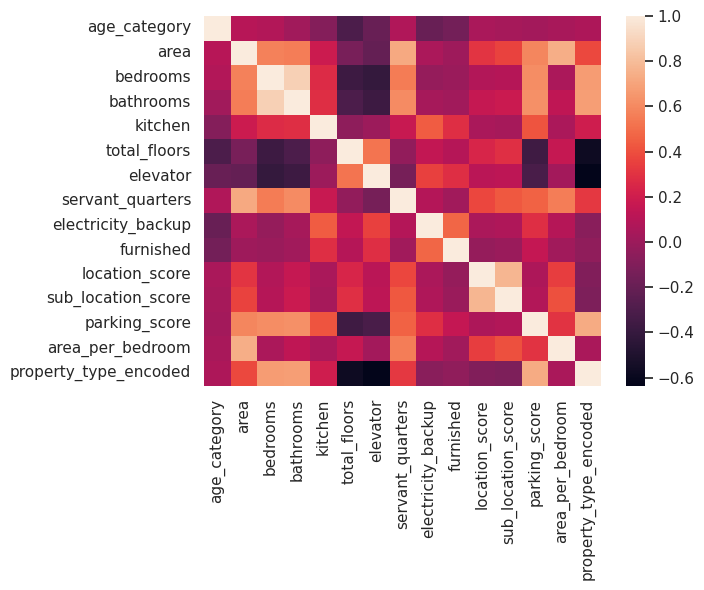

In [ ]:
corr_cols = [
    "age_category",
    "area",
    "bedrooms",
    "bathrooms",
    "kitchen",
    "total_floors",
    "elevator",
    "servant_quarters",
    "electricity_backup",
    "furnished",
    "location_score",
    "sub_location_score",
    "parking_score",
    "area_per_bedroom",
    "property_type_encoded"
]

sns.heatmap(X_encoded_df[corr_cols].corr())

In [ ]:
corr_df = X_encoded_df[corr_cols].copy()


corr_df["price"] = y.values

price_corr = corr_df.corr()["price"].sort_values(ascending=False)

print(price_corr)

price                    1.000000
area                     0.835341
servant_quarters         0.601424
area_per_bedroom         0.570581
parking_score            0.532385
bathrooms                0.506449
bedrooms                 0.504888
sub_location_score       0.445491
location_score           0.367513
property_type_encoded    0.363577
kitchen                  0.186913
electricity_backup       0.042210
age_category             0.023958
furnished                0.020943
total_floors            -0.093508
elevator                -0.196158
Name: price, dtype: float64


In [ ]:
fi_df1 = price_corr.reset_index()
fi_df1.columns = ["feature", "Correlation"]

In [ ]:
fi_df1

,feature,Correlation
0,price,1.000000
1,area,0.835341
2,servant_quarters,0.601424
3,area_per_bedroom,0.570581
4,parking_score,0.532385
5,bathrooms,0.506449
6,bedrooms,0.504888
7,sub_location_score,0.445491
8,location_score,0.367513
9,property_type_encoded,0.363577


# Technique 2 - Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100, random_state=42 ,n_jobs=-1)

rf.fit(corr_df[corr_cols],corr_df['price'])

fi_df2=pd.DataFrame({"feature":corr_cols,"importance":rf.feature_importances_}).sort_values("importance",ascending=False)
fi_df2

,feature,importance
1,area,0.736878
11,sub_location_score,0.071374
0,age_category,0.032289
13,area_per_bedroom,0.032070
2,bedrooms,0.022024
10,location_score,0.019999
5,total_floors,0.018030
4,kitchen,0.018011
3,bathrooms,0.013251
12,parking_score,0.009163


# Technique 3 - Gradient Boosting Feature importances

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

X_fs = corr_df[corr_cols]
y_fs = corr_df["price"]


gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_fs, y_fs)


fi_df3 = pd.DataFrame({"feature": X_fs.columns,"gb_importance": gb.feature_importances_}).sort_values(by="gb_importance",ascending=False)

fi_df3

,feature,gb_importance
1,area,0.819565
11,sub_location_score,0.081230
2,bedrooms,0.022989
10,location_score,0.019730
0,age_category,0.019332
13,area_per_bedroom,0.009646
5,total_floors,0.008072
3,bathrooms,0.006497
14,property_type_encoded,0.005774
4,kitchen,0.002552


# Technique 4 - Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_fs = corr_df[corr_cols]; y_fs = corr_df["price"]

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_fs, y_train_fs)

perm_importance = permutation_importance(rf, X_test_fs, y_test_fs, n_repeats=30, random_state=42, n_jobs=-1)

fi_df4 = pd.DataFrame({"feature": X_fs.columns, "permutation_importance": perm_importance.importances_mean}).sort_values(by="permutation_importance", ascending=False)

fi_df4

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature,permutation_importance
1,area,0.914419
11,sub_location_score,0.208201
10,location_score,0.080748
0,age_category,0.049452
14,property_type_encoded,0.024694
4,kitchen,0.014790
5,total_floors,0.010782
2,bedrooms,0.010754
7,servant_quarters,0.010132
12,parking_score,0.009514


# Technique 5 - LASSO

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler


X_fs = corr_df[corr_cols]
y_fs = corr_df["price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fs)

lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y_fs)

fi_df5 = pd.DataFrame({"feature": X_fs.columns,"lasso_coeff": lasso.coef_,"abs_lasso_coeff": abs(lasso.coef_)}).sort_values("abs_lasso_coeff", ascending=False)
fi_df5

,feature,lasso_coeff,abs_lasso_coeff
1,area,9.416598e+07,9.416598e+07
11,sub_location_score,2.174031e+07,2.174031e+07
13,area_per_bedroom,-1.920861e+07,1.920861e+07
14,property_type_encoded,9.740266e+06,9.740266e+06
0,age_category,-7.046577e+06,7.046577e+06
2,bedrooms,-6.731423e+06,6.731423e+06
7,servant_quarters,-6.143945e+06,6.143945e+06
12,parking_score,4.709233e+06,4.709233e+06
8,electricity_backup,-4.684023e+06,4.684023e+06
3,bathrooms,-3.204674e+06,3.204674e+06


# Technique 6 - RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X_fs = corr_df[corr_cols].copy()
y_fs = corr_df["price"]

estimator = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit the random forest and collect its feature importance scores.
estimator.fit(X_fs, y_fs)

rf_importance = estimator.feature_importances_

# Rank the features with recursive feature elimination.
selector = RFE(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    n_features_to_select=1,
    step=1
)

selector.fit(X_fs, y_fs)

# Confirm that the feature counts line up across the results.
print(len(X_fs.columns))
print(len(selector.ranking_))
print(len(rf_importance))

# Combine the feature rankings and importance scores into one table.
fi_df6 = pd.DataFrame({
    "feature": list(X_fs.columns),
    "rfe_rank": selector.ranking_,
    "rf_importance": rf_importance
}).sort_values(by="rfe_rank")

fi_df6

15
15
15


,feature,rfe_rank,rf_importance
1,area,1,0.736878
11,sub_location_score,2,0.071374
13,area_per_bedroom,3,0.032070
0,age_category,4,0.032289
2,bedrooms,5,0.022024
5,total_floors,6,0.018030
4,kitchen,7,0.018011
10,location_score,8,0.019999
3,bathrooms,9,0.013251
12,parking_score,10,0.009163


# Technique 7 - Linear Regression Weights

In [ ]:
from sklearn.linear_model import  LinearRegression
lin_reg = LinearRegression()
y_fs=corr_df['price']/10_000_000
lin_reg.fit(X_scaled, y_fs)

# Collect the linear-model coefficients for each feature.
fi_df7 = pd.DataFrame({
    'feature': X_fs.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
1,area,9.416598
11,sub_location_score,2.174031
14,property_type_encoded,0.974027
12,parking_score,0.470923
9,furnished,0.283010
10,location_score,0.253382
4,kitchen,0.233587
5,total_floors,0.219717
6,elevator,-0.159547
3,bathrooms,-0.320467


In [ ]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature')

In [ ]:
final_fi_df

,feature,Correlation,importance,gb_importance,permutation_importance,lasso_coeff,abs_lasso_coeff,rfe_rank,rf_importance,reg_coeffs
0,area,0.835341,0.736878,0.819565,0.914419,9.416598e+07,9.416598e+07,1,0.736878,9.416598
1,servant_quarters,0.601424,0.007741,0.002040,0.010132,-6.143945e+06,6.143945e+06,12,0.007741,-0.614394
2,area_per_bedroom,0.570581,0.032070,0.009646,0.007565,-1.920861e+07,1.920861e+07,3,0.032070,-1.920861
3,parking_score,0.532385,0.009163,0.001795,0.009514,4.709233e+06,4.709233e+06,10,0.009163,0.470923
4,bathrooms,0.506449,0.013251,0.006497,0.008686,-3.204674e+06,3.204674e+06,9,0.013251,-0.320467
5,bedrooms,0.504888,0.022024,0.022989,0.010754,-6.731423e+06,6.731423e+06,5,0.022024,-0.673142
6,sub_location_score,0.445491,0.071374,0.081230,0.208201,2.174031e+07,2.174031e+07,2,0.071374,2.174031
7,location_score,0.367513,0.019999,0.019730,0.080748,2.533817e+06,2.533817e+06,8,0.019999,0.253382
8,property_type_encoded,0.363577,0.007816,0.005774,0.024694,9.740266e+06,9.740266e+06,11,0.007816,0.974027
9,kitchen,0.186913,0.018011,0.002552,0.014790,2.335872e+06,2.335872e+06,7,0.018011,0.233587


In [ ]:
numeric_cols = final_fi_df.columns.drop("feature")
final_fi_df[numeric_cols] = final_fi_df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
  )

In [ ]:
feature_col = final_fi_df[["feature"]]
numeric_df = final_fi_df.drop(columns=["feature"])
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")
normalized_df = numeric_df.divide(numeric_df.sum(axis=0), axis=1)
final_fi_df = pd.concat([feature_col, normalized_df], axis=1)

In [ ]:
final_fi_df = final_fi_df.set_index("feature")

In [ ]:

final_fi_df[['importance','rf_importance','gb_importance','permutation_importance']].mean(axis=1).sort_values(ascending=False)

,0
feature,
area,0.741353
sub_location_score,0.094251
age_category,0.030064
location_score,0.029769
area_per_bedroom,0.019837
bedrooms,0.018736
total_floors,0.013014
kitchen,0.012361
property_type_encoded,0.009889


In [ ]:
from sklearn.model_selection import cross_val_score
rf=RandomForestRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(rf,X_fs,y_fs,cv=5,scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8315329775782908)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_fs.drop(columns=['elevator']), y_fs, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8326133200220923)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_fs.drop(columns=['elevator','electricity_backup']), y_fs, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8313770879350779)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_fs.drop(columns=['elevator','electricity_backup','furnished']), y_fs, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.831632684904176)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_fs.drop(columns=['electricity_backup','furnished']), y_fs, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8308076320083678)

In [68]:
export_df = X_encoded_df.drop(columns=['elevator'])
export_df['price']=y_fs

In [69]:
export_df.to_csv('karachi_properties_post_feature_selection.csv', index=False)


In [70]:
export_df.head()

,district_Karachi Central,district_Karachi East,district_Karachi South,district_Korangi,district_Malir,district_Multi-District,location_Bahria Town,location_Clifton,location_DHA Defence,location_Federal B Area,location_Gadap,location_Gulistan-e-Jauhar,location_Gulshan-e-Iqbal Town,location_Jamshed Town,location_Karsaz,location_Korangi,location_Malir,location_Malir Cantt,location_Naya Nazimabad,location_Nazimabad,location_North Karachi,location_North Nazimabad,location_Saddar Town,location_Scheme 33,location_Shah Faisal,location_Super Highway,sub_location_Adamjee Nagar,sub_location_Airport,sub_location_Allahwala Town,sub_location_Amil Colony,sub_location_Amir Khusro,sub_location_Askari 4,sub_location_Askari 5,sub_location_Askari 6,sub_location_Bahadurabad,sub_location_Bahria Apartments,sub_location_Bahria Heights,sub_location_Bahria Paradise,sub_location_Bahria Sports City,sub_location_Bahria Town_Unspecified,sub_location_Bath Island,sub_location_Buffer Zone,sub_location_Civil Lines,sub_location_Clifton Block 1,sub_location_Clifton Block 2,sub_location_Clifton Block 3,sub_location_Clifton Block 4,sub_location_Clifton Block 5,sub_location_Clifton Block 6,sub_location_Clifton Block 7,sub_location_Clifton Block 8,sub_location_Clifton Block 9,sub_location_Clifton_Unspecified,sub_location_Cosmopolitan Society,"sub_location_Cp Barar Society, Gulshan-E-Iqbal Town",sub_location_DHA City,sub_location_DHA Defence_Unspecified,sub_location_Defence View,sub_location_Dhoraji Colony,sub_location_Dohs Phase 1,sub_location_Dohs Phase 2,sub_location_Falaknaz,sub_location_Falcon Complex Faisal,sub_location_Falcon Complex New Malir,sub_location_Federal B Area Block 10,sub_location_Federal B Area Block 11,sub_location_Federal B Area Block 12,sub_location_Federal B Area Block 13,sub_location_Federal B Area Block 14,sub_location_Federal B Area Block 15,sub_location_Federal B Area Block 16,sub_location_Federal B Area Block 19,sub_location_Federal B Area Block 20,sub_location_Federal B Area Block 21,sub_location_Federal B Area Block 6,sub_location_Federal B Area Block 7,sub_location_Federal B Area Block 8,sub_location_Federal B Area Block 9,sub_location_Federal B Area_Unspecified,sub_location_Frere Town,sub_location_Garden East,sub_location_Garden West,sub_location_Gizri,sub_location_Gohar Green City Cluster,sub_location_Golden Town,sub_location_Green Town / Rafah-E-Aam Belt,sub_location_Gulistan-e-Jauhar Block 1,sub_location_Gulistan-e-Jauhar Block 10,sub_location_Gulistan-e-Jauhar Block 11,sub_location_Gulistan-e-Jauhar Block 12,sub_location_Gulistan-e-Jauhar Block 13,sub_location_Gulistan-e-Jauhar Block 14,sub_location_Gulistan-e-Jauhar Block 15,sub_location_Gulistan-e-Jauhar Block 16,sub_location_Gulistan-e-Jauhar Block 16A,sub_location_Gulistan-e-Jauhar Block 17,sub_location_Gulistan-e-Jauhar Block 18,sub_location_Gulistan-e-Jauhar Block 19,sub_location_Gulistan-e-Jauhar Block 2,sub_location_Gulistan-e-Jauhar Block 20,sub_location_Gulistan-e-Jauhar Block 3,sub_location_Gulistan-e-Jauhar Block 3A,sub_location_Gulistan-e-Jauhar Block 4,sub_location_Gulistan-e-Jauhar Block 5,sub_location_Gulistan-e-Jauhar Block 7,sub_location_Gulistan-e-Jauhar Block 8,sub_location_Gulistan-e-Jauhar Block 9,sub_location_Gulistan-e-Jauhar_Unspecified,sub_location_Gulshan-E-Maymar,sub_location_Gulshan-e-Iqbal Block 1,sub_location_Gulshan-e-Iqbal Block 10,sub_location_Gulshan-e-Iqbal Block 10A,sub_location_Gulshan-e-Iqbal Block 11,sub_location_Gulshan-e-Iqbal Block 13,sub_location_Gulshan-e-Iqbal Block 13A,sub_location_Gulshan-e-Iqbal Block 13B,sub_location_Gulshan-e-Iqbal Block 13C,sub_location_Gulshan-e-Iqbal Block 13D,sub_location_Gulshan-e-Iqbal Block 13D1,sub_location_Gulshan-e-Iqbal Block 13D2,sub_location_Gulshan-e-Iqbal Block 13D3,sub_location_Gulshan-e-Iqbal Block 14,sub_location_Gulshan-e-Iqbal Block 16,sub_location_Gulshan-e-Iqbal Block 17,sub_location_Gulshan-e-Iqbal Block 19,sub_location_Gulshan-e-Iqbal Block 2,sub_location_Gulshan-e-Iqbal Block 21,sub_locat